In [199]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re
from pathlib import Path
import string
import pickle

from functools import partial

In [200]:
from imblearn.pipeline import Pipeline # supports for oversampling step
# from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split)
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    roc_auc_score,
    f1_score)

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression  # TODO we can also use this
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.decomposition import TruncatedSVD

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [201]:
from umap import UMAP
from sklearn.manifold import TSNE

In [202]:
from rital.data import (
    load_presidents,
    load_presidents_unseen,
)

from rital.movies.data import (
    load_movies,
    load_movies_unseen
)
from rital.preprocessing import (
    compute_odds_ratio,
    plot_frequencies,
    plot_word_cloud
)

from rital.presidents.preprocessing import (
    preprocess,
    tokenizer
)

from rital.presidents.analysis import (
    plot_roc_pr,
    ordered_train_test_split,
    plot_train_test_cm,
    TextStats
)

from rital.presidents.postprocessing import (
    smooth,
    plot_smoothing,
    calibrate_proba,
    adjust_threshold,
    adjust_proba,
    SmoothLogisticRegression
)
PLOTS_DIR = "../plots/"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [203]:
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

## Data Loading

In [234]:
PRESIDENTS = True

if PRESIDENTS:
    FILE_RADICAL = "pres-"
    X_train_full, y_train_full = load_presidents()
    X_test_unseen =load_presidents_unseen()
    label2name = {
    0 : "Chirac",
    1 : "Mitterrand"
}
    X_train_full_embeddings = np.load("X_train_full_embeddings.npy")
    STEMMER = SnowballStemmer("french")
    STOP_WORDS = stopwords.words("french")
else:
    FILE_RADICAL = "mov-"
    X_train_full, y_train_full = load_movies()
    X_train_full, y_train_full = np.array(X_train_full), np.array(y_train_full)
    X_test_unseen = np.array(load_movies_unseen())
    label2name = {
        0 : "negative",
        1 : "positive"
    }
    X_train_full_embeddings = None
    STEMMER = SnowballStemmer("english")
    STOP_WORDS = stopwords.words("english")



## Train-test split preserving order

In [235]:
FIT_ON_UNSEEN = False
if FIT_ON_UNSEEN:
    X_train = X_train_full
    y_train = y_train_full
    X_test = X_test_unseen
    y_test = None # Unseen
    
    X_test_embeddings = None  # X_test_unseen_embeddings # Not done yet
    X_train_embeddings = X_train_full_embeddings

else:    
    X_train, X_train_embeddings, y_train, X_test, X_test_embeddings, y_test = ordered_train_test_split(
        X_train_full, y_train_full, X_train_full_embeddings,
        test_size=0.2, random_state=2, 
        shuffle = False,
        stratify=False
        )
    print(f"Original imbalance: { (y_train_full == 0).sum() / (y_train_full == 1).sum() :.2f}")
    print(f"Train imbalance: {(y_train == 0).sum() / (y_train == 1).sum() :.2f}")
    print(f"Test imbalance: {(y_test == 0).sum() / (y_test == 1).sum() :.2f}")
    # NOTE: test set is less balanced, so performance is underestimated

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', 
                                    classes=classes, 
                                    y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}
sample_weights = np.array([class_weight_dict[y] for y in y_train])

Original imbalance: 6.63
Train imbalance: 6.22
Test imbalance: 8.87


# FastText

Similar to Word2Vec, performs better for French. Does CBOW or Skip-Gram as well but on subword level, so it can compute embeddings of words that never appeared in training!

In [206]:
import fasttext 
# fasttext.util.download_model('fr'/'en', if_exists='ignore')
from gensim.models import KeyedVectors
if PRESIDENTS:
    ft = fasttext.load_model('cc.fr.300.bin')
else:
    ft = fasttext.load_model('cc.en.300.bin')

In [207]:
vectorizer = TfidfVectorizer(preprocessor=partial(preprocess, lowercase=True, take_exceptions=False),
                            tokenizer=tokenizer,
                            lowercase=True,
                            ngram_range=(1,1),
                            max_df=0.9,
                            min_df=3,
                            stop_words=STOP_WORDS,)
        

X_counts = vectorizer.fit_transform(X_train_full)
vocab = vectorizer.get_feature_names_out()
odds_ratio = compute_odds_ratio(X_counts, y_train_full)
log_odds = np.log2(odds_ratio)
discriminative_mask = np.abs(log_odds) > (3.1 if PRESIDENTS else 1)
vocab = vocab[discriminative_mask]
log_odds = log_odds[discriminative_mask]
len(vocab)

/Users/vlad/Documents/University/Master-MIND/nlp-document-classification/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


194

In [208]:
word_embeddings = np.empty((len(vocab),ft.get_dimension()))
for i, word in enumerate(vocab):
    word_embeddings[i] = ft.get_word_vector(word)
umap = UMAP(n_neighbors=10, min_dist=0.5, metric='cosine')
X_umap = umap.fit_transform(word_embeddings)

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_50380/2000577342.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


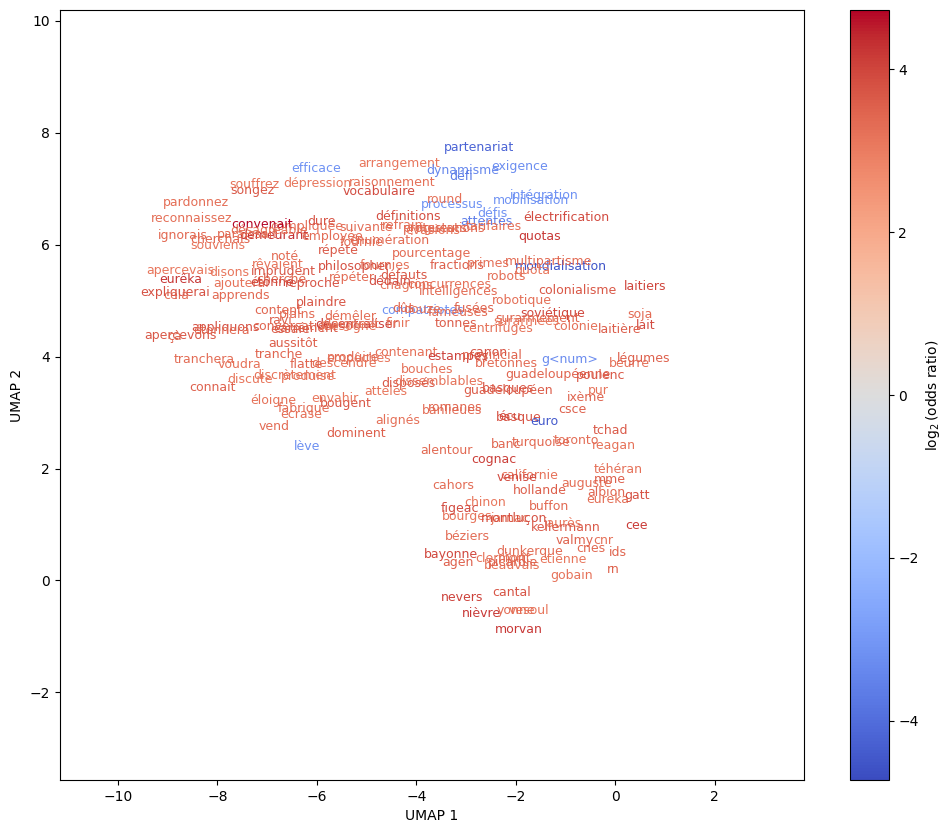

In [209]:
fig, ax = plt.subplots(figsize=(12, 10))

# Normalize log_odds for color mapping
max_abs = np.max(np.abs(log_odds))
norm = mcolors.Normalize(vmin=-max_abs, vmax=max_abs)
cmap = cm.get_cmap('coolwarm')

texts = []
for i, label in enumerate(vocab):
    color = cmap(norm(log_odds[i]))

    text = ax.text(
        X_umap[i, 0],
        X_umap[i, 1],
        label,
        fontsize=9,
        # alpha= np.abs(log_odds[i]) / max_abs,
        ha='right',
        va='bottom',
        color=color
    )
    texts.append(text)

# Set limits
margin = 3#0.05
x_min, x_max = X_umap[:, 0].min(), X_umap[:, 0].max()
y_min, y_max = X_umap[:, 1].min(), X_umap[:, 1].max()
ax.set_xlim(x_min - margin, x_max + margin)
ax.set_ylim(y_min - margin, y_max + margin)

# adjust_text(texts, X_umap[:, 0], X_umap[:, 1], expand_text=(10, 14))
adjust_text(
    texts,
    X_umap[:, 0],
    X_umap[:, 1],
    expand_text=(1.2, 1.4),
    force_text=(1.0, 1.5),
    force_points=(0.5, 1.0),
    lim=300
)

# Proper colorbar attachment
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label='$\\log_2$(odds ratio)')

# ax.set_title("UMAP on FastText Word Embeddings")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig(PLOTS_DIR + FILE_RADICAL + "umap_fasttext_words.pdf")
plt.show()

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_50380/1177570228.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


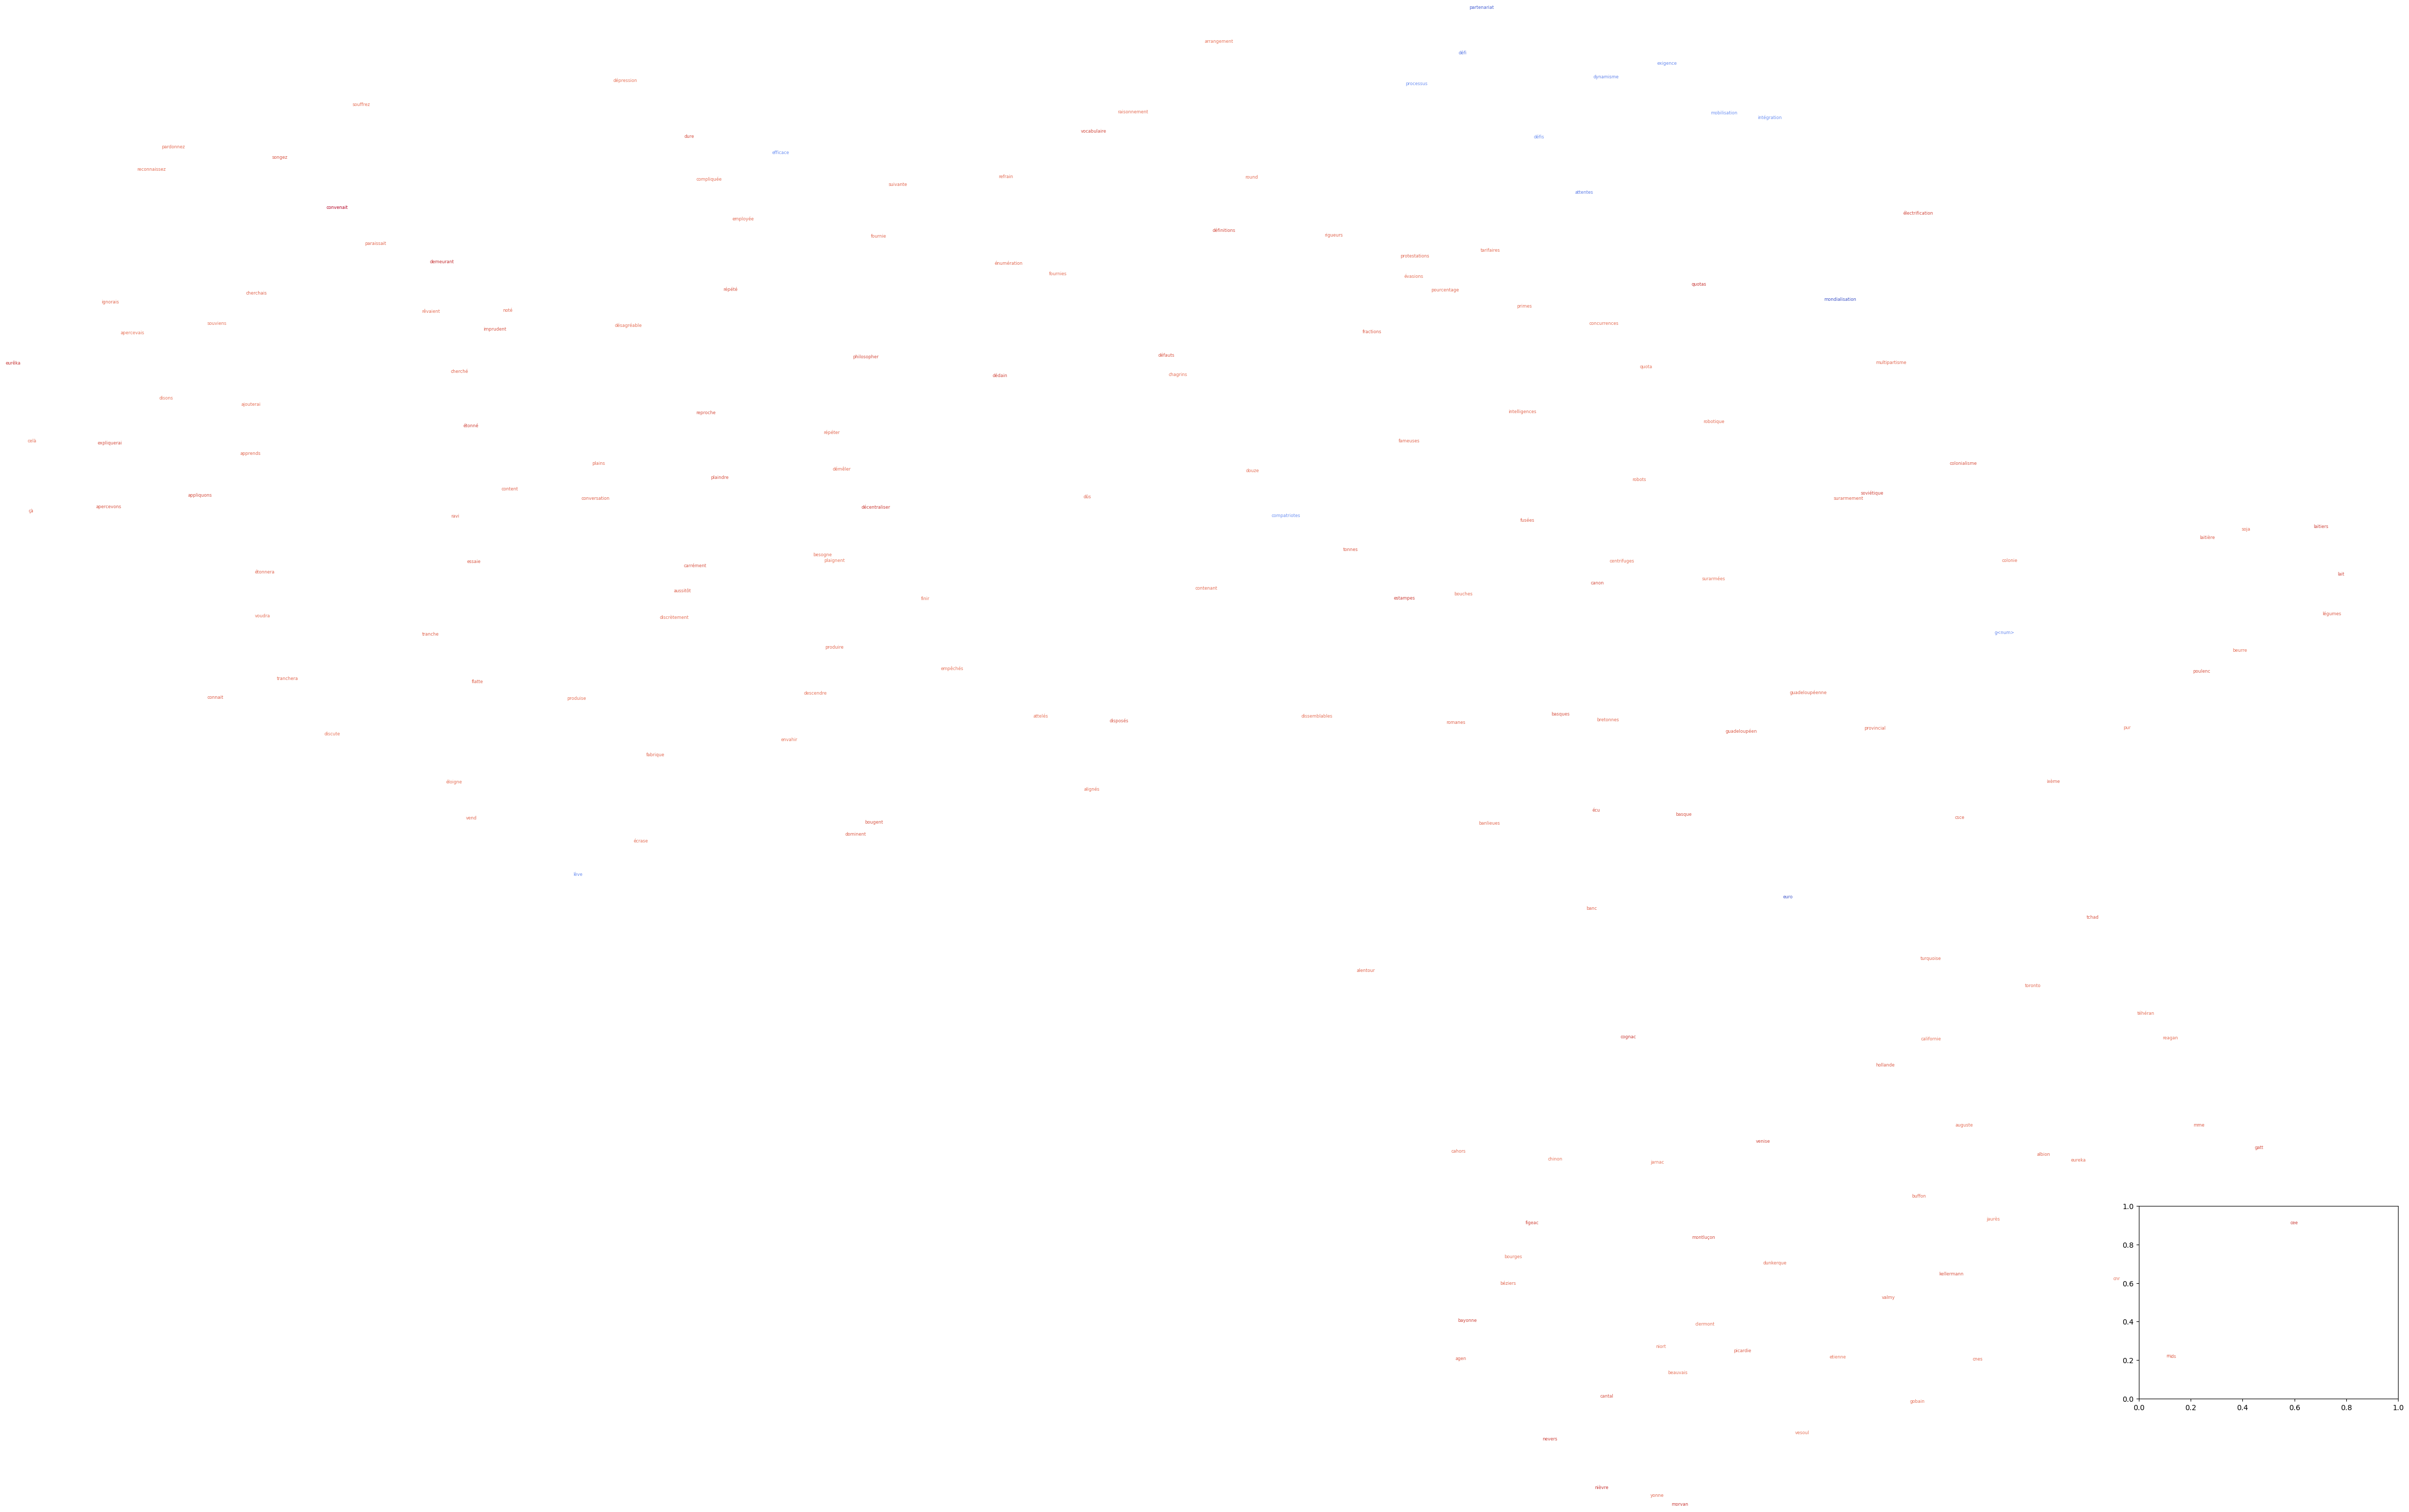

In [210]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Normalize values exactly like scatter
norm = mcolors.Normalize(vmin=-max_abs, vmax=max_abs)
cmap = cm.get_cmap('coolwarm')

texts = []
for i, label in enumerate(vocab):
    color = cmap(norm(log_odds[i]))  # map value → color

    text = plt.text(
        X_umap[i, 0],
        X_umap[i, 1],
        label,
        fontsize=6,
        ha='right',
        va='bottom',
        color=color   # <-- key change
    )
    texts.append(text)

## Crete Document Embeddings

In [211]:
X_train_full_ft = np.empty((len(X_train_full),ft.get_dimension()*3))
for i, doc in enumerate(X_train_full):
    mean_embedding = np.zeros(ft.get_dimension())
    max_embedding = np.zeros(ft.get_dimension()) - np.inf
    min_embedding = np.zeros(ft.get_dimension()) + np.inf
    doc_len = 0
    for word in doc.split():
        word_embedding = ft.get_word_vector(word)
        mean_embedding += word_embedding
        max_embedding = np.maximum(max_embedding, word_embedding)
        min_embedding = np.minimum(min_embedding, word_embedding)
        doc_len += 1
    mean_embedding /= doc_len
    doc_embedding = np.hstack([mean_embedding, min_embedding, max_embedding])
    X_train_full_ft[i] = doc_embedding

In [212]:
colors = ("#3C5488", "#E64B35")

In [213]:
PLOT_DIMRED= False
if PLOT_DIMRED:

    umap = UMAP(n_neighbors=100, min_dist=0.5, metric='cosine')

    X_umap = umap.fit_transform(X_train_full_ft)
    for label, color in enumerate(colors):
        plt.scatter(X_umap[y_train_full == label,0],X_umap[y_train_full == label,1], c=color, alpha=0.1)
        plt.title("UMAP on FastText embeddings")
    plt.show()

    # tsne = TSNE()

    # X_tsne = tsne.fit_transform(X_train_full_ft)
    # plt.scatter(X_tsne[:,0],X_tsne[:,1], c=y_train_full, alpha=0.1)
    # plt.title("tSNE on FastText embeddings")
    # plt.show()

In [214]:
X_train, X_train_ft, y_train, X_test, X_test_ft, y_test = ordered_train_test_split(
    X_train_full, y_train_full,X_train_full_ft, #np.hstack([X_train_full_ft, X_train_full_embeddings]),
    test_size=0.2, random_state=2, 
    shuffle = False,
    stratify=False
    )

In [227]:

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', 
                                    classes=classes, 
                                    y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}

# Assign sample weights
sample_weights = np.array([class_weight_dict[y] for y in y_train])

# Instantiate XGBoost classifier
clf = LogisticRegression(class_weight="balanced")#XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Fit with sample weights to handle imbalance
clf.fit(X_train_ft, y_train)#, sample_weight=sample_weights)

# Predictions
y_pred = clf.predict(X_test_ft)



/Users/vlad/Documents/University/Master-MIND/nlp-document-classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


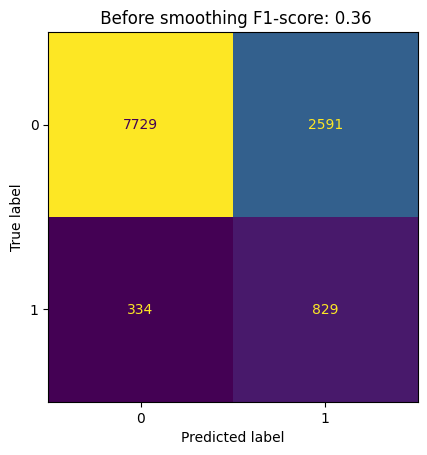

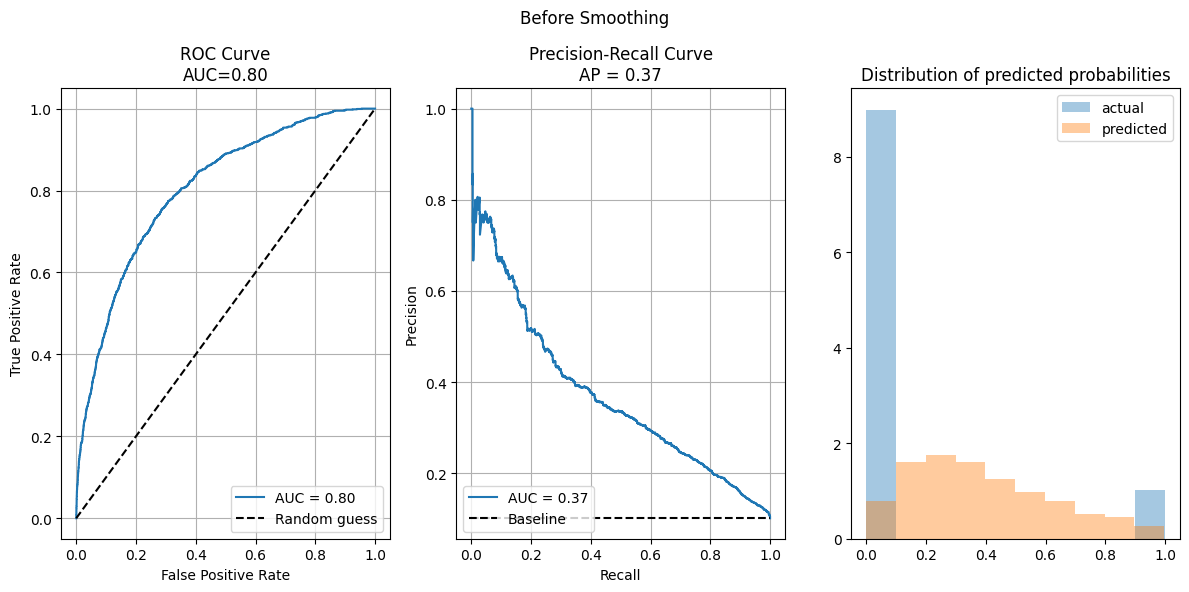

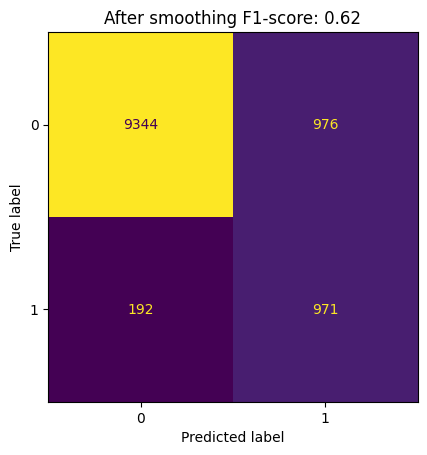

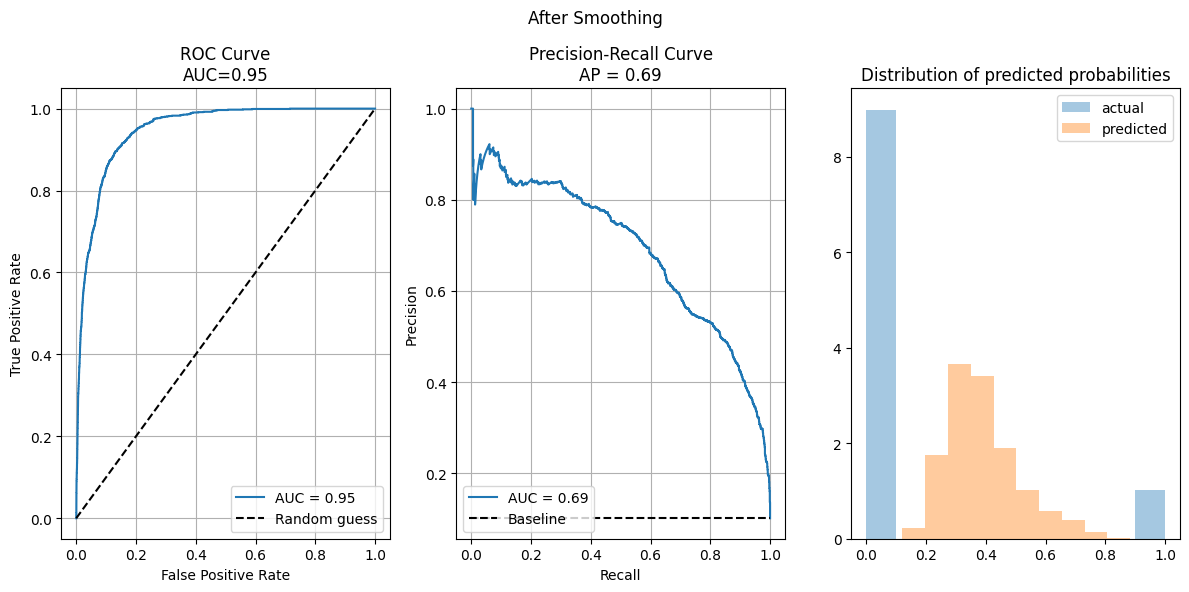

In [232]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
plt.title(f" Before smoothing F1-score: {f1_score(y_test, y_pred):.2f}")
plt.show()

# Get predicted probabilities for the positive class
y_proba = clf.predict_proba(X_test_ft)[:, 1]

threshold = 0.5
y_test_pred_smooth = smooth(adjust_proba(y_proba, threshold), size=17)
# y_train_pred_smooth = smooth(adjust_proba(y_train_pred, threshold), size=17)
plot_roc_pr(y_test, y_proba, title="Before Smoothing")
plt.savefig("../plots/pres-curves_before_smoothing_camembert.pdf")
plt.show()


ConfusionMatrixDisplay.from_predictions(y_test, (y_test_pred_smooth >0.5).astype(int), colorbar=False)
plt.title(f"After smoothing F1-score: {f1_score(y_test, (y_test_pred_smooth >0.5).astype(int)):.2f}")
plt.show()

plot_roc_pr(y_test, y_test_pred_smooth, title="After Smoothing")
plt.savefig("../plots/pres-curves_after_smoothing_camembert.pdf")
plt.show()

# Camembert Embeddings

Embeddings of `[CLS]` token of each sentence.

In [244]:

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', 
                                    classes=classes, 
                                    y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}

# Assign sample weights
sample_weights = np.array([class_weight_dict[y] for y in y_train])

# Instantiate XGBoost classifier
clf = LogisticRegression(class_weight="balanced")#XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Fit with sample weights to handle imbalance
clf.fit(X_train_embeddings, y_train)#, sample_weight=sample_weights)

# Predictions
y_pred = clf.predict(X_test_embeddings)


# Get predicted probabilities for the positive class
y_proba = clf.predict_proba(X_test_embeddings)[:, 1]

/Users/vlad/Documents/University/Master-MIND/nlp-document-classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


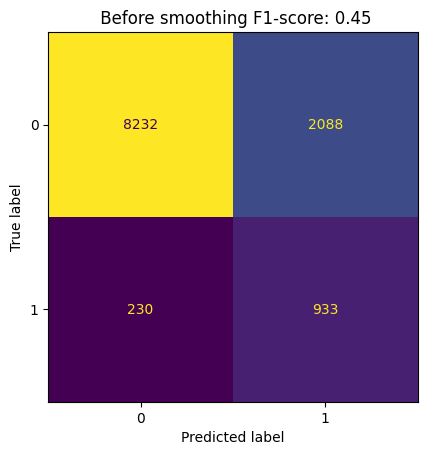

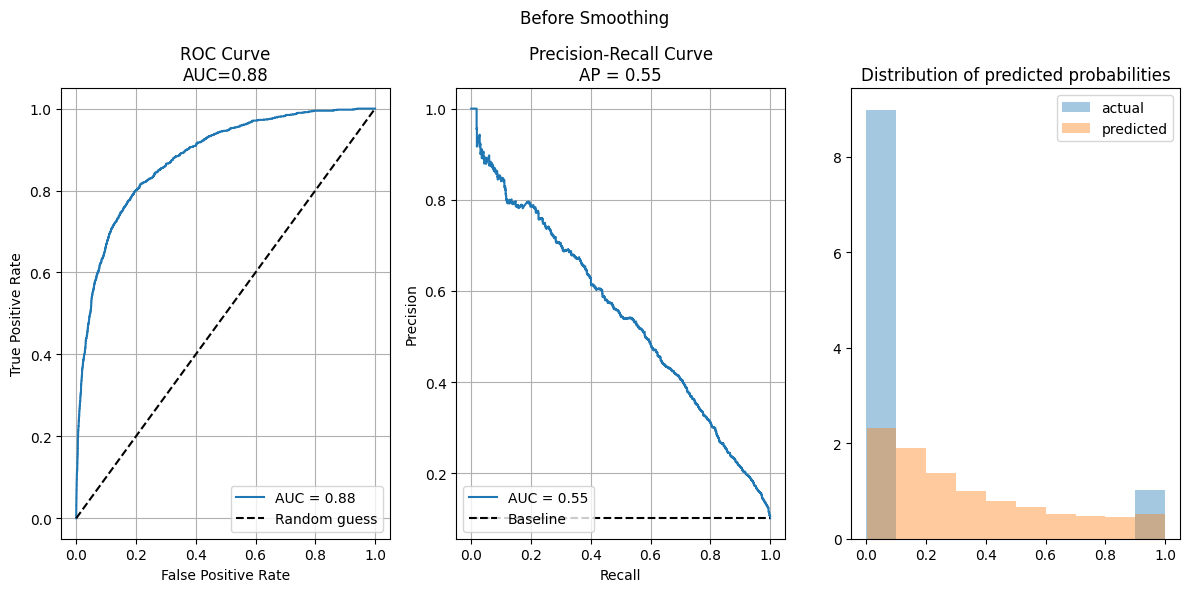

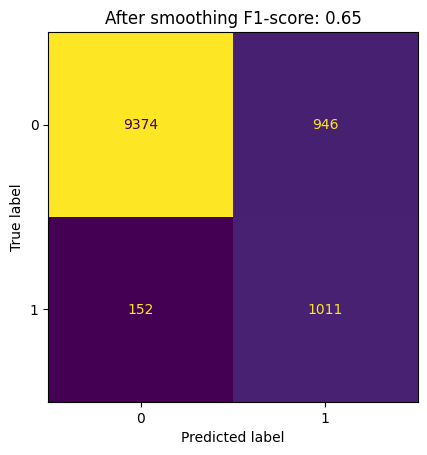

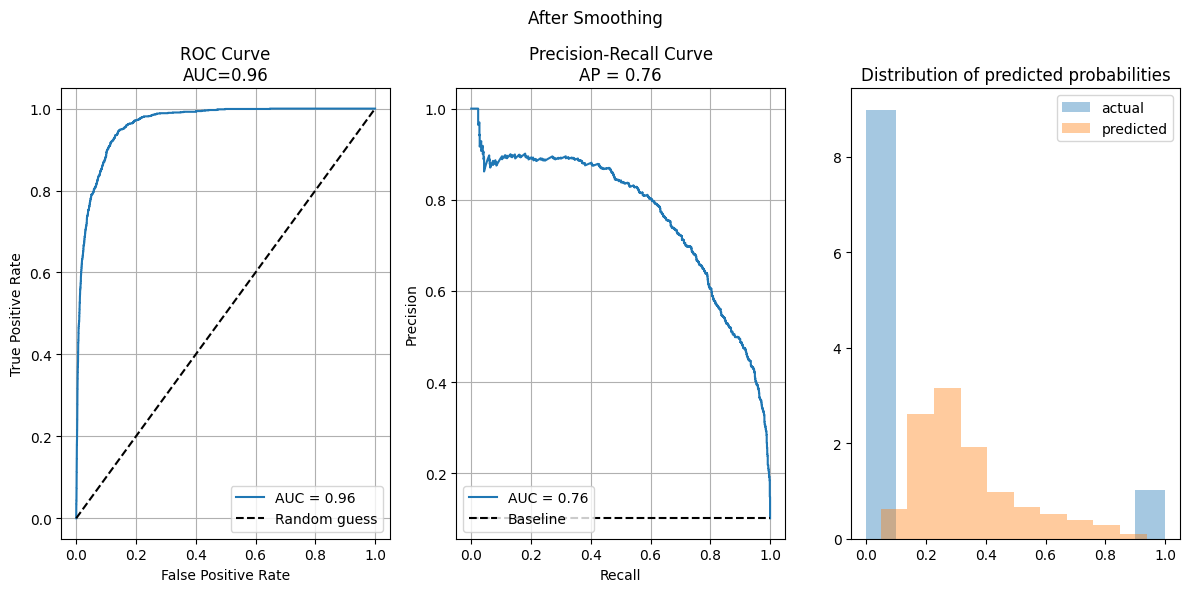

In [248]:
# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
plt.title(f" Before smoothing F1-score: {f1_score(y_test, y_pred):.2f}")
plt.show()


threshold = 0.5
y_test_pred_smooth = smooth(adjust_proba(y_proba, threshold), size=17)
# y_train_pred_smooth = smooth(adjust_proba(y_train_pred, threshold), size=17)
plot_roc_pr(y_test, y_proba, title="Before Smoothing")
plt.savefig("../plots/pres-curves_before_smoothing_camembert.pdf")
plt.show()


ConfusionMatrixDisplay.from_predictions(y_test, (y_test_pred_smooth >0.5).astype(int), colorbar=False)
plt.title(f"After smoothing F1-score: {f1_score(y_test, (y_test_pred_smooth >0.5).astype(int)):.2f}")
plt.show()

plot_roc_pr(y_test, y_test_pred_smooth, title="After Smoothing")
plt.savefig("../plots/pres-curves_after_smoothing_camembert.pdf")
plt.show()